# Inspect jobsub grid DDIM outputs

Unpacks `out_*.tgz` from a pnfs campaign dir, checks manifests / pickles / arrays,
and plots original / reconstruction / saliency (per-patch and optional stitched plane).
Also loads **`*_ad_metrics.npz`** when present (weighted MSE, latent L2, denoise loss,
posterior typicality, …) and compares score distributions.

**Kernel:** local `env` is fine (files are on `/pnfs`). Grid pickles are NumPy 2.x;
this notebook rebuilds patch arrays from `*_arrays.npz` so NumPy 1.x kernels work too.

Related: `02_CompareReconstructions.ipynb` (single local pickle),
`analysis/AnalyzeDDIM2DDIM_Outputs.ipynb` (ROC / metrics),
`inference/ad_metrics.py` (score definitions).

In [5]:
from __future__ import annotations

import json
import pickle
import shutil
import sys
import tarfile
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np

APP_ROOT = Path("/exp/sbnd/app/users/munjung/anomaly-detection")
sys.path.insert(0, str(APP_ROOT))
sys.path.insert(0, str(APP_ROOT / "inference"))

from configs.paths import DATA_ROOT  # noqa: E402
from run_ddim2ddim_inference import stitch_patches  # noqa: E402
from ad_metrics import (  # noqa: E402
    METRIC_NAMES,
    calibrate_scores,
    compute_pixel_metrics_from_arrays_npz,
    file_score_from_patch_scores,
    load_ad_metrics_npz,
    pixel_metric_maps,
)

PNFS_OUT = Path("/pnfs/sbnd/scratch/users/munjung/anomaly-detection/out/inference")

# --- Configure: pick a campaign directory under PNFS_OUT ---
CAMPAIGN = PNFS_OUT / "2026_09_15_011947__handscan_T200_smoke6g_v3"

# Local extract dir (avoid writing large unpacks to nashome)
UNPACK_ROOT = DATA_ROOT / "inference" / "grid_unpacked" / CAMPAIGN.name

T = None  # e.g. 50 / 100 / 200; None → first available T in the job
MODE = "ddim2ddim"
PATCH_ORDINAL = 0  # which patch to plot in the per-file view
JOB_TO_PLOT = None  # e.g. 6, or None → first job that has a tarball

print("campaign", CAMPAIGN)
print("exists", CAMPAIGN.is_dir())
print("unpack →", UNPACK_ROOT)
print("numpy", np.__version__)

campaign /pnfs/sbnd/scratch/users/munjung/anomaly-detection/out/inference/2026_09_15_011947__handscan_T200_smoke6g_v3
exists True
unpack → /exp/sbnd/data/users/munjung/anomaly-detection/inference/grid_unpacked/2026_09_15_011947__handscan_T200_smoke6g_v3
numpy 1.23.5


## Campaign inventory

In [6]:
assert CAMPAIGN.is_dir(), CAMPAIGN

tgzs = sorted(CAMPAIGN.glob("out_*.tgz"))
logs = sorted(CAMPAIGN.glob("log_*.log"))
print(f"{len(tgzs)} tarball(s), {len(logs)} log(s)\n")

rows = []
for tgz in tgzs:
    job = int(tgz.stem.split("_")[1])
    log = CAMPAIGN / f"log_{job}.log"
    rows.append(
        {
            "job": job,
            "tgz_MB": tgz.stat().st_size / 1e6,
            "log_KB": log.stat().st_size / 1e3 if log.is_file() else None,
            "tgz": tgz.name,
        }
    )

for r in rows:
    print(f"job {r['job']:2d}: {r['tgz_MB']:6.1f} MB  log={r['log_KB']} KB  {r['tgz']}")

done_jobs = {r["job"] for r in rows}
log_jobs = {int(p.stem.split("_")[1]) for p in logs}
pending = sorted(log_jobs - done_jobs)
if pending:
    print("\nlogs present but no out_*.tgz yet:", pending)

10 tarball(s), 10 log(s)

job  0:   24.5 MB  log=11.605 KB  out_0.tgz
job  1:   24.5 MB  log=11.605 KB  out_1.tgz
job  2:   24.5 MB  log=11.605 KB  out_2.tgz
job  3:   24.5 MB  log=11.609 KB  out_3.tgz
job  4:   24.5 MB  log=11.609 KB  out_4.tgz
job  5:   24.5 MB  log=11.59 KB  out_5.tgz
job  6:   24.4 MB  log=11.588 KB  out_6.tgz
job  7:   24.4 MB  log=11.584 KB  out_7.tgz
job  8:   24.5 MB  log=11.588 KB  out_8.tgz
job  9:   24.5 MB  log=11.609 KB  out_9.tgz


## Unpack tarballs

In [7]:
UNPACK_ROOT.mkdir(parents=True, exist_ok=True)

def unpack_job(tgz: Path, force: bool = False) -> Path:
    job = int(tgz.stem.split("_")[1])
    dest = UNPACK_ROOT / f"job_{job}"
    marker = dest / ".unpacked"
    if marker.is_file() and not force:
        return dest
    if dest.exists() and force:
        shutil.rmtree(dest)
    dest.mkdir(parents=True, exist_ok=True)
    with tarfile.open(tgz, "r:gz") as tf:
        tf.extractall(dest)
    marker.write_text(tgz.name + "\n")
    return dest

unpacked = {int(t.stem.split("_")[1]): unpack_job(t) for t in tgzs}
print("unpacked jobs:", sorted(unpacked))
for j, d in sorted(unpacked.items()):
    files = sorted(p.relative_to(d) for p in d.rglob("*") if p.is_file() and p.name != ".unpacked")
    print(f"  job {j}:", [str(f) for f in files])

unpacked jobs: [0, 1, 2, 3, 4, 5, 6, 7, 8, 9]
  job 0: ['out_0/86414745_63_g4-raw-0_10.h5_7_T200_ddim2ddim.pkl', 'out_0/86414745_63_g4-raw-0_10.h5_7_T200_ddim2ddim_arrays.npz', 'out_0/86414745_63_g4-raw-0_10.h5_7_T200_meta.json', 'out_0/manifest_T200.json']
  job 1: ['out_1/86414745_63_g4-raw-0_10.h5_8_T200_ddim2ddim.pkl', 'out_1/86414745_63_g4-raw-0_10.h5_8_T200_ddim2ddim_arrays.npz', 'out_1/86414745_63_g4-raw-0_10.h5_8_T200_meta.json', 'out_1/manifest_T200.json']
  job 2: ['out_2/86414745_63_g4-raw-0_10.h5_9_T200_ddim2ddim.pkl', 'out_2/86414745_63_g4-raw-0_10.h5_9_T200_ddim2ddim_arrays.npz', 'out_2/86414745_63_g4-raw-0_10.h5_9_T200_meta.json', 'out_2/manifest_T200.json']
  job 3: ['out_3/86414745_63_g4-raw-0_11.h5_1_T200_ddim2ddim.pkl', 'out_3/86414745_63_g4-raw-0_11.h5_1_T200_ddim2ddim_arrays.npz', 'out_3/86414745_63_g4-raw-0_11.h5_1_T200_meta.json', 'out_3/manifest_T200.json']
  job 4: ['out_4/86414745_63_g4-raw-0_11.h5_8_T200_ddim2ddim.pkl', 'out_4/86414745_63_g4-raw-0_11.h5_8_T20

## Validate one job (structure + shapes)

In [19]:
def find_out_dir(job_root: Path) -> Path:
    cands = [p for p in job_root.iterdir() if p.is_dir() and p.name.startswith("out_")]
    if not cands:
        raise FileNotFoundError(f"no out_* under {job_root}")
    return cands[0]


def _results_from_arrays(arrays, meta: dict, T_use: int) -> dict:
    """Rebuild the per-patch pickle dict from *_arrays.npz (NumPy 1/2 safe)."""
    keys = meta.get("pickle_keys_per_patch") or [
        "original",
        f"{MODE}-T{T_use}",
        f"saliency-T{T_use}",
    ]
    orig, reco, sal = arrays["original"], arrays["reconstructed"], arrays["saliency"]
    n = int(meta["n_patches"])
    results = {
        i: {keys[0]: orig[i], keys[1]: reco[i], keys[2]: sal[i]} for i in range(n)
    }
    results[f"__{MODE}_source__"] = {
        "input_filename": str(arrays["input_filename"]),
        "input_path": str(arrays["input_path"]),
        "input_relative_to_scan_root": str(arrays["input_relative_to_scan_root"]),
    }
    return results


def load_job(job: int, T: int | None = None):
    out_dir = find_out_dir(unpacked[job])
    available = sorted(
        {
            int(p.name.split("_T")[1].split("_")[0])
            for p in out_dir.glob(f"*_T*_{MODE}_arrays.npz")
        }
    )
    if not available:
        # older campaigns may only have pickles
        available = sorted(
            {
                int(p.name.split("_T")[1].split("_")[0])
                for p in out_dir.glob(f"*_T*_{MODE}.pkl")
            }
        )
    if not available:
        raise FileNotFoundError(f"no *_T*_{MODE}_{{arrays.npz,pkl}} under {out_dir}")
    T_use = int(T) if T is not None else available[0]
    if T_use not in available:
        raise FileNotFoundError(f"T={T_use} not in {available} for job {job}")
    pkls = list(out_dir.glob(f"*_T{T_use}_{MODE}.pkl"))
    npzs = list(out_dir.glob(f"*_T{T_use}_{MODE}_arrays.npz"))
    meta = json.loads(next(out_dir.glob(f"*_T{T_use}_meta.json")).read_text())
    man_path = out_dir / f"manifest_T{T_use}.json"
    man = json.loads(man_path.read_text()) if man_path.is_file() else {}

    arrays = np.load(npzs[0], allow_pickle=True) if npzs else None
    results = None
    if arrays is not None:
        results = _results_from_arrays(arrays, meta, T_use)
    elif pkls:
        # NumPy 2 pickles need numpy._core; shim helps some 1.x kernels
        try:
            with pkls[0].open("rb") as f:
                results = pickle.load(f)
        except ModuleNotFoundError as e:
            if "numpy._core" not in str(e):
                raise
            import numpy.core as _numpy_core

            sys.modules.setdefault("numpy._core", _numpy_core)
            sys.modules.setdefault("numpy._core.multiarray", _numpy_core.multiarray)
            with pkls[0].open("rb") as f:
                results = pickle.load(f)
    else:
        raise FileNotFoundError(f"no arrays.npz or pkl for T={T_use} under {out_dir}")

    return {
        "out_dir": out_dir,
        "pkl": pkls[0] if pkls else None,
        "results": results,
        "meta": meta,
        "manifest": man,
        "arrays": arrays,
        "T": T_use,
        "available_T": available,
    }


job = JOB_TO_PLOT if JOB_TO_PLOT is not None else sorted(unpacked)[0]
job = 2
bundle = load_job(job, T)
results = bundle["results"]
meta = bundle["meta"]
T = bundle["T"]  # resolve auto-pick for later cells
int_keys = sorted(k for k in results if isinstance(k, int))
src = results.get(f"__{MODE}_source__", {})

print("job", job)
print("available T", bundle["available_T"], "→ plotting T", T)
print("pkl", bundle["pkl"].name if bundle["pkl"] else "(none; using arrays.npz)")
print("source", src)
print("meta T", meta["T"], "n_patches", meta["n_patches"], "layouts", meta.get("layouts_per_frame"))
print("patch keys", int_keys)
print("per-patch keys", meta.get("pickle_keys_per_patch"))
if bundle["arrays"] is not None:
    print(
        "arrays.npz",
        {
            k: bundle["arrays"][k].shape
            for k in bundle["arrays"].files
            if hasattr(bundle["arrays"][k], "shape")
        },
    )

assert int_keys == list(range(meta["n_patches"]))
for i in int_keys:
    d = results[i]
    for k in ("original", f"{MODE}-T{T}", f"saliency-T{T}"):
        a = np.asarray(d[k])
        assert a.shape[-2:] == (512, 512), (i, k, a.shape)
        assert np.isfinite(a).all(), (i, k)
print("structure OK")

job 2
available T [200] → plotting T 200
pkl 86414745_63_g4-raw-0_10.h5_9_T200_ddim2ddim.pkl
source {'input_filename': '86414745_63_g4-raw-0_10.h5_9.npz', 'input_path': '/srv/anomaly-detection-ana/inputs/86414745_63_g4-raw-0_10.h5_9.npz', 'input_relative_to_scan_root': '86414745_63_g4-raw-0_10.h5_9.npz'}
meta T 200 n_patches 6 layouts [{'patch_size': [512, 512], 'grid_shape': [1, 6], 'cropped_shape': [512, 3072], 'full_plane_shape': [512, 3072], 'npz_frame': 0}]
patch keys [0, 1, 2, 3, 4, 5]
per-patch keys ['original', 'ddim2ddim-T200', 'saliency-T200']
arrays.npz {'original': (6, 1, 512, 512), 'reconstructed': (6, 1, 512, 512), 'saliency': (6, 1, 512, 512), 'input_filename': (), 'input_path': (), 'input_relative_to_scan_root': ()}
structure OK


## Plot one patch (original / reco / saliency)

job 2 patch 3: |reco-orig| mean=0.007629


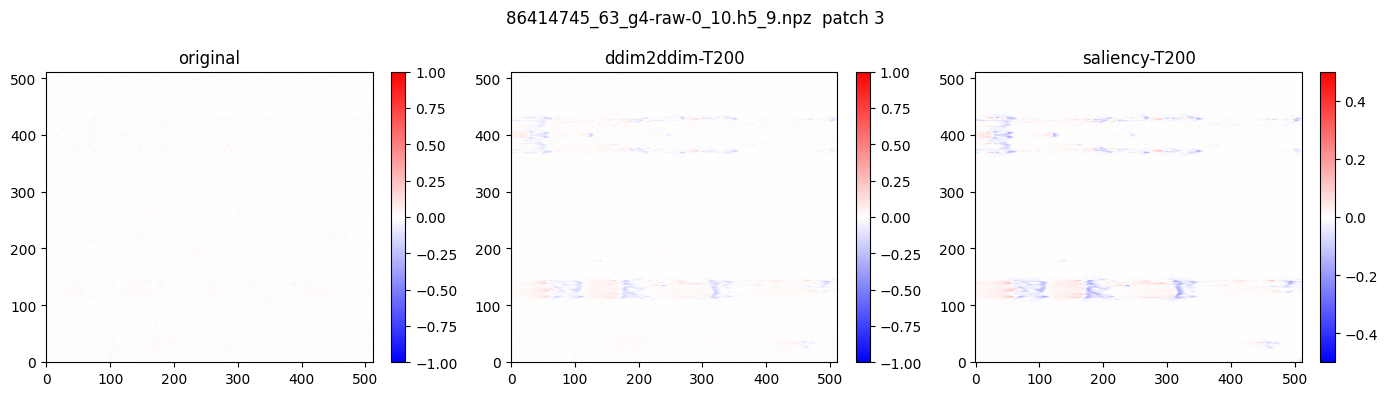

In [22]:
# i = int_keys[PATCH_ORDINAL]
i = 3
sample = results[i]
orig = np.squeeze(sample["original"])
reco = np.squeeze(sample[f"{MODE}-T{T}"])
sal = np.squeeze(sample[f"saliency-T{T}"])

print(f"job {job} patch {i}: |reco-orig| mean={np.mean(np.abs(reco - orig)):.4g}")

fig, ax = plt.subplots(1, 3, figsize=(14, 4))
for a, img, title, vmin, vmax in [
    (ax[0], orig, "original", -1, 1),
    (ax[1], reco, f"{MODE}-T{T}", -1, 1),
    (ax[2], sal, f"saliency-T{T}", -0.5, 0.5),
]:
    im = a.imshow(img, aspect="auto", origin="lower", cmap="bwr", vmin=vmin, vmax=vmax)
    a.set_title(title)
    fig.colorbar(im, ax=a, fraction=0.046)
fig.suptitle(f"{src.get('input_filename') or (bundle['pkl'].name if bundle['pkl'] else '')}  patch {i}")
plt.tight_layout()
plt.show()

## Stitched plane (all patches)

stitched shapes (512, 3072) (512, 3072) (512, 3072)


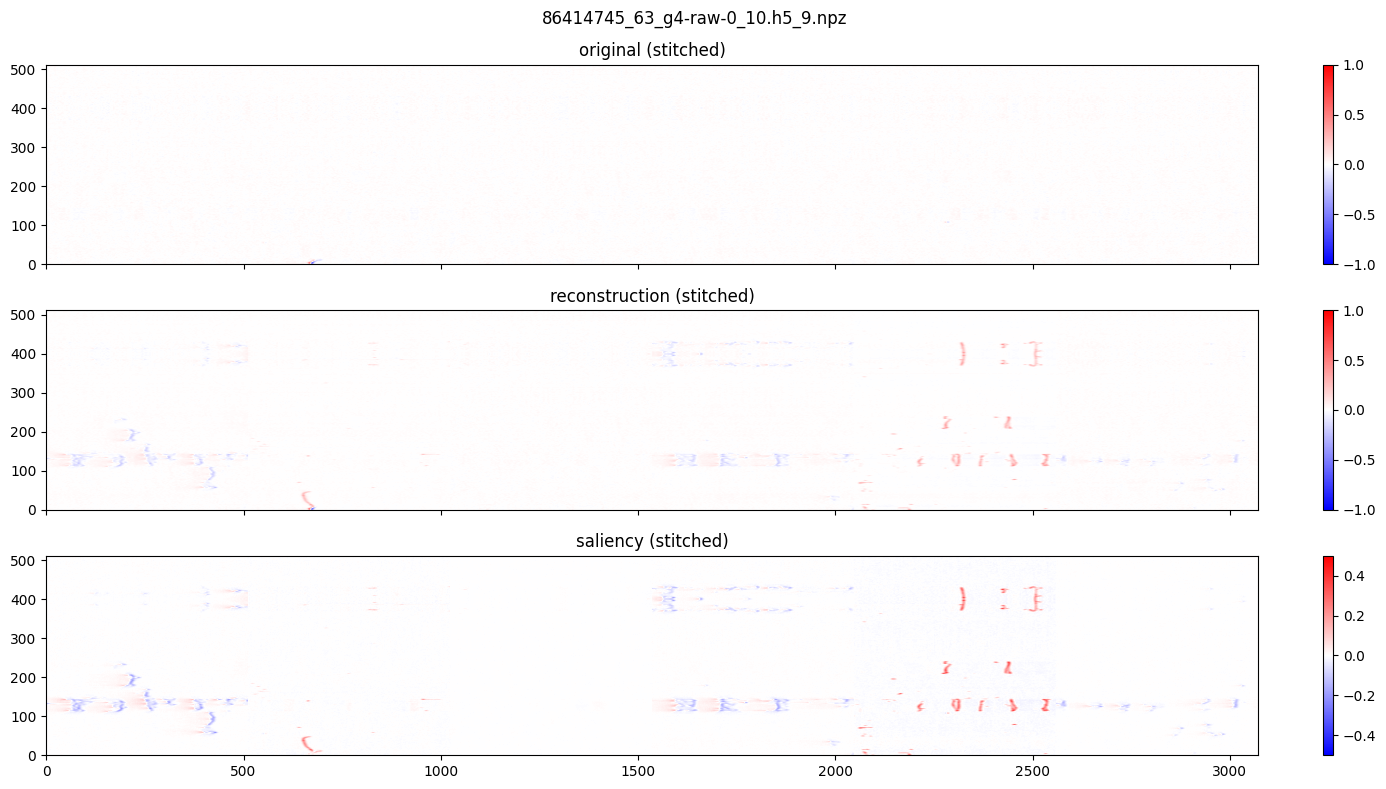

In [23]:
layout = meta["layouts_per_frame"][0]
grid = tuple(layout["grid_shape"])
ph, pw = layout["patch_size"]

orig_stack = np.stack([np.squeeze(results[k]["original"]) for k in int_keys], axis=0)
reco_stack = np.stack([np.squeeze(results[k][f"{MODE}-T{T}"]) for k in int_keys], axis=0)
sal_stack = np.stack([np.squeeze(results[k][f"saliency-T{T}"]) for k in int_keys], axis=0)

plane_o = stitch_patches(orig_stack, grid, (ph, pw))
plane_r = stitch_patches(reco_stack, grid, (ph, pw))
plane_s = stitch_patches(sal_stack, grid, (ph, pw))
print("stitched shapes", plane_o.shape, plane_r.shape, plane_s.shape)

fig, ax = plt.subplots(3, 1, figsize=(14, 8), sharex=True)
for a, img, title, vmin, vmax in [
    (ax[0], plane_o, "original (stitched)", -1, 1),
    (ax[1], plane_r, "reconstruction (stitched)", -1, 1),
    (ax[2], plane_s, "saliency (stitched)", -0.5, 0.5),
]:
    im = a.imshow(img, aspect="auto", origin="lower", cmap="bwr", vmin=vmin, vmax=vmax)
    a.set_title(title)
    fig.colorbar(im, ax=a, fraction=0.02)
fig.suptitle(src.get("input_filename", ""))
plt.tight_layout()
plt.show()

## Optional: skim a worker log

In [24]:
log_path = CAMPAIGN / f"log_{job}.log"
if log_path.is_file():
    text = log_path.read_text(errors="replace")
    lines = text.strip().splitlines()
    print(f"{log_path.name}: {len(lines)} lines, {log_path.stat().st_size/1e3:.1f} KB")
    print("--- head ---")
    print("\n".join(lines[:15]))
    print("--- tail ---")
    print("\n".join(lines[-20:]))
else:
    print("no log for job", job)

log_2.log: 37 lines, 11.6 KB
--- head ---
[run_2.sh] starting
[run_2.sh] using dropbox model.pt
-rwxr-xr-x 1 munjung fnalgrid 137M Sep 15 06:24 ./model.pt
[run_2.sh] input 0: /pnfs/sbnd/scratch/users/munjung/anomaly-detection/inputs/handscan_test/86414745_63_g4-raw-0_10.h5_9.npz
total 604K
-rwxr-xr-x 1 munjung fnalgrid 601K Sep 15 06:24 86414745_63_g4-raw-0_10.h5_9.npz
timestepresp1 
numberinchannels 1
steps 1000 [1000]
predict_xstart False
predict_xprev False
model_mean_type ModelMeanType.EPSILON
num_timesteps 1000
sectioncount [1000]
all steps {0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16, 17, 18, 19, 20, 21, 22, 23, 24, 25, 26, 27, 28, 29, 30, 31, 32, 33, 34, 35, 36, 37, 38, 39, 40, 41, 42, 43, 44, 45, 46, 47, 48, 49, 50, 51, 52, 53, 54, 55, 56, 57, 58, 59, 60, 61, 62, 63, 64, 65, 66, 67, 68, 69, 70, 71, 72, 73, 74, 75, 76, 77, 78, 79, 80, 81, 82, 83, 84, 85, 86, 87, 88, 89, 90, 91, 92, 93, 94, 95, 96, 97, 98, 99, 100, 101, 102, 103, 104, 105, 106, 107, 108, 109, 110, 11

## AD metrics (multi-score comparison)

Jobs write `{stem}_T{T}_{mode}_ad_metrics.npz` with per-patch scores:
`mse`, `weighted_mse`, `noise_region_mse`, `latent_l2`, `denoise_loss`,
`posterior_typicality` (NaN if `--ad-posterior-k 0`).

If the metrics file is missing (older campaigns), pixel scores are recomputed
from `*_arrays.npz`. Model-based scores need a re-submit with metrics enabled.


In [ ]:
def find_ad_metrics(out_dir: Path, stem: str, T: int, mode: str) -> Path | None:
    cands = [
        out_dir / f"{stem}_T{T}_{mode}_ad_metrics.npz",
        *out_dir.glob(f"**/{stem}_T{T}_{mode}_ad_metrics.npz"),
    ]
    for p in cands:
        if p.is_file():
            return p
    return None


def find_arrays(out_dir: Path, stem: str, T: int, mode: str) -> Path | None:
    cands = [
        out_dir / f"{stem}_T{T}_{mode}_arrays.npz",
        *out_dir.glob(f"**/{stem}_T{T}_{mode}_arrays.npz"),
    ]
    for p in cands:
        if p.is_file():
            return p
    return None


def load_scores_for_job(job: int, T_use: int | None = None, mode: str = MODE):
    """Return dict metric -> (N_patches,) and metadata."""
    out_dir = find_out_dir(unpacked[job])
    metas = sorted(out_dir.glob("*_meta.json")) + sorted(out_dir.glob("**/*_meta.json"))
    # unique by resolve
    seen = set()
    meta_paths = []
    for m in metas:
        r = m.resolve()
        if r not in seen:
            seen.add(r)
            meta_paths.append(m)
    if not meta_paths:
        raise FileNotFoundError(f"no meta under {out_dir}")
    # pick meta matching T
    chosen = None
    for mp in meta_paths:
        meta = json.loads(mp.read_text())
        if T_use is None or int(meta.get("T", -1)) == int(T_use):
            chosen = (mp, meta)
            if T_use is not None:
                break
    if chosen is None:
        chosen = (meta_paths[0], json.loads(meta_paths[0].read_text()))
    mp, meta = chosen
    T_eff = int(meta["T"])
    stem = Path(meta.get("input_filename") or meta.get("source_npz", "x.npz")).stem
    mpath = find_ad_metrics(out_dir, stem, T_eff, mode)
    apath = find_arrays(out_dir, stem, T_eff, mode)
    scores = {}
    source = None
    if mpath is not None:
        z = load_ad_metrics_npz(mpath)
        for name in METRIC_NAMES:
            if name in z:
                scores[name] = np.asarray(z[name], dtype=np.float64)
        source = f"ad_metrics:{mpath.name}"
    elif apath is not None:
        pix = compute_pixel_metrics_from_arrays_npz(apath)
        scores.update({k: np.asarray(v, dtype=np.float64) for k, v in pix.items()})
        source = f"arrays_recompute:{apath.name}"
    else:
        raise FileNotFoundError(f"no ad_metrics or arrays for {stem} T={T_eff} under {out_dir}")
    return {
        "job": job,
        "stem": stem,
        "T": T_eff,
        "mode": mode,
        "scores": scores,
        "source": source,
        "arrays": apath,
        "meta": meta,
    }


# Demo: one job
job = JOB_TO_PLOT if JOB_TO_PLOT is not None else sorted(unpacked)[0]
one = load_scores_for_job(job, T_use=T)
print(f"job={one['job']} stem={one['stem']} T={one['T']} source={one['source']}")
for k, v in one["scores"].items():
    vv = v[np.isfinite(v)]
    if vv.size:
        print(f"  {k:22s} n={vv.size}  mean={vv.mean():.4e}  max={vv.max():.4e}")
    else:
        print(f"  {k:22s} (all nan — not computed in this job)")


In [ ]:
# Collect file-level scores across all unpacked jobs
rows = []
for job in sorted(unpacked):
    try:
        info = load_scores_for_job(job, T_use=T)
    except Exception as e:
        print(f"skip job {job}: {e}")
        continue
    for metric, patch_s in info["scores"].items():
        rows.append(
            {
                "job": info["job"],
                "stem": info["stem"],
                "T": info["T"],
                "metric": metric,
                "score_max": file_score_from_patch_scores(patch_s, "max"),
                "score_mean": file_score_from_patch_scores(patch_s, "mean"),
                "n_patches": int(np.asarray(patch_s).size),
                "source": info["source"],
            }
        )

import pandas as pd

scores_df = pd.DataFrame(rows)
print(f"rows={len(scores_df)} jobs={scores_df['job'].nunique() if len(scores_df) else 0}")
if len(scores_df):
    display(scores_df.groupby("metric")[["score_max", "score_mean"]].describe().round(6))


In [ ]:
# Histograms: compare metrics side-by-side (file-max reduction)
if len(scores_df) == 0:
    print("No scores to plot")
else:
    metrics_present = [m for m in METRIC_NAMES if m in set(scores_df["metric"])]
    # drop all-nan metrics
    metrics_present = [
        m for m in metrics_present
        if np.isfinite(scores_df.loc[scores_df["metric"] == m, "score_max"]).any()
    ]
    n = len(metrics_present)
    fig, axes = plt.subplots(1, n, figsize=(3.2 * n, 3.2), squeeze=False)
    for ax, m in zip(axes[0], metrics_present):
        s = scores_df.loc[scores_df["metric"] == m, "score_max"].to_numpy()
        s = s[np.isfinite(s)]
        ax.hist(s, bins=min(20, max(5, len(s) // 2)), color="C0", alpha=0.85)
        ax.set_title(m)
        ax.set_xlabel("file-max score")
        ax.set_ylabel("count")
    fig.suptitle(f"Campaign AD metrics (T={T or 'auto'}, mode={MODE})")
    fig.tight_layout()
    plt.show()


In [ ]:
# Weighted-MSE map vs plain |saliency| for one patch (recomputed from arrays)
info = load_scores_for_job(job, T_use=T)
apath = info["arrays"]
if apath is None:
    print("No arrays.npz — cannot plot weighted map")
else:
    z = np.load(apath)
    orig = z["original"]
    reco = z["reconstructed"]
    sal = z["saliency"]
    maps = pixel_metric_maps(orig, reco)
    i = int(PATCH_ORDINAL) % len(orig)
    o = np.squeeze(orig[i])
    r = np.squeeze(reco[i])
    s = np.squeeze(sal[i])
    wse = np.squeeze(maps["weighted_sq_err"][i])
    fig, axes = plt.subplots(1, 4, figsize=(14, 3.5))
    for ax, img, title, cmap in [
        (axes[0], o, "original", "gray"),
        (axes[1], r, "reco", "gray"),
        (axes[2], s, "saliency (reco-orig)", "coolwarm"),
        (axes[3], wse, "weighted sq err", "magma"),
    ]:
        if cmap == "coolwarm":
            v = float(np.nanpercentile(np.abs(img), 99)) or 1e-3
            im = ax.imshow(img.T, origin="lower", aspect="auto", cmap=cmap, vmin=-v, vmax=v)
        elif cmap == "magma":
            im = ax.imshow(img.T, origin="lower", aspect="auto", cmap=cmap)
        else:
            v = float(np.nanpercentile(np.abs(img), 99)) or 1e-3
            im = ax.imshow(img.T, origin="lower", aspect="auto", cmap=cmap, vmin=-v, vmax=v)
        ax.set_title(title)
        ax.set_xlabel("wire")
        ax.set_ylabel("tick")
        fig.colorbar(im, ax=ax, fraction=0.046)
    fig.suptitle(f"{info['stem']} patch {i}  T={info['T']}")
    fig.tight_layout()
    plt.show()
    print("patch scores:")
    for k, v in info["scores"].items():
        if i < len(v):
            print(f"  {k:22s} {float(v[i]):.6e}")
